**Predicting Irrigation Need** - https://www.kaggle.com/competitions/playground-series-s6e4/overview

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_train = pd.read_csv('irrigation_train.csv')
df_train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
df_test = pd.read_csv('irrigation_test.csv')
df_test.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [5]:
print(f"Train Set Shape : {df_train.shape}")
print(f"Test Set Shape : {df_test.shape}")

Train Set Shape : (630000, 21)
Test Set Shape : (270000, 20)


In [6]:
test_id = df_test['id']
submission_df = pd.DataFrame({'id': test_id})

In [7]:
ntrain = df_train.shape[0]    # No of rows in Train dataset
ntest = df_test.shape[0]      # No of rows in Test dataset
df_train['Irrigation_Need'] = df_train['Irrigation_Need'].map({"Low":0, "Medium":1, "High":2})
ytrain = df_train['Irrigation_Need']

# Combined Dataset
df = pd.concat([df_train, df_test]).reset_index(drop=True)
df.drop(['Irrigation_Need'], axis=1, inplace=True)
print(f"Size of the whole dataset : {df.shape}")

Size of the whole dataset : (900000, 20)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900000 entries, 0 to 899999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       900000 non-null  int64  
 1   Soil_Type                900000 non-null  object 
 2   Soil_pH                  900000 non-null  float64
 3   Soil_Moisture            900000 non-null  float64
 4   Organic_Carbon           900000 non-null  float64
 5   Electrical_Conductivity  900000 non-null  float64
 6   Temperature_C            900000 non-null  float64
 7   Humidity                 900000 non-null  float64
 8   Rainfall_mm              900000 non-null  float64
 9   Sunlight_Hours           900000 non-null  float64
 10  Wind_Speed_kmh           900000 non-null  float64
 11  Crop_Type                900000 non-null  object 
 12  Crop_Growth_Stage        900000 non-null  object 
 13  Season                   900000 non-null  object 
 14  Irri

- There are no null values in the dataset
- The target feature to be predicted is the `Irrigation_Need`

**Check for Duplicate Rows in Dataset**

In [9]:
df.duplicated().sum()

np.int64(0)

- No duplicate rows in the dataset.

**Pre-processing Data**

In [10]:
df = df.drop(['id'], axis=1)
df_train = df_train.drop(['id'], axis=1)

- Dropping column `id` as it cannot contribute to the irrigation need prediction

In [11]:
# Checking the values in the categorical columns
for col in df.select_dtypes(include='object'):
    print(df[col].value_counts(normalize=True)*100)
    print('-'*50)

Soil_Type
Sandy    26.422444
Clay     25.156111
Loamy    24.816222
Silt     23.605222
Name: proportion, dtype: float64
--------------------------------------------------
Crop_Type
Sugarcane    17.224444
Rice         16.939778
Cotton       16.621000
Maize        16.568778
Wheat        16.384111
Potato       16.261889
Name: proportion, dtype: float64
--------------------------------------------------
Crop_Growth_Stage
Harvest       26.631222
Flowering     25.008667
Vegetative    24.980556
Sowing        23.379556
Name: proportion, dtype: float64
--------------------------------------------------
Season
Kharif    34.383778
Rabi      33.008222
Zaid      32.608000
Name: proportion, dtype: float64
--------------------------------------------------
Irrigation_Type
Canal        25.729333
Sprinkler    25.663111
Rainfed      24.667000
Drip         23.940556
Name: proportion, dtype: float64
--------------------------------------------------
Water_Source
Reservoir      25.880222
River          25.3

In [12]:
categorical_cols = list(df.select_dtypes(include='object'))
numerical_cols = list(df.select_dtypes(include=['int', 'float']))

# EDA

## Univariate Analysis

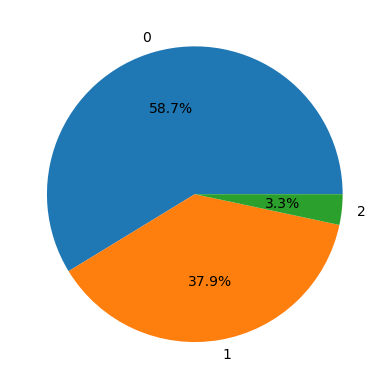

In [13]:
plt.pie(
    x = df_train['Irrigation_Need'].value_counts(),
    labels = df_train['Irrigation_Need'].unique(),
    autopct="%1.1f%%"
);

- Imbalanced data with ~59% of samples with `Low` irrigation need, ~38% samples with `Medium` irrigation need and only 3% with `High` irrigation needs

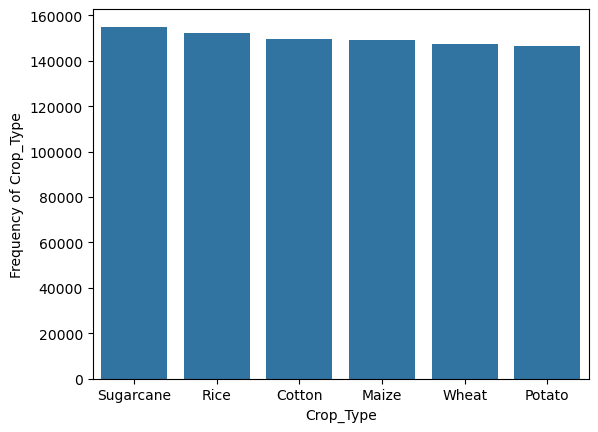

In [14]:
crop_type_order = df['Crop_Type'].value_counts().index
plt.ylabel('Frequency of Crop_Type')
sns.countplot(df, x='Crop_Type', order=crop_type_order);

**Notes** :

- Sugarcane - perennial (full year) cash crop ---> needs high/good amount of irrigation
- Rice - food crop ---> needs flooded fields (standing water) ---> most consumption of water, ie, high amount of irrigation
- Cotton - cash crop ----> needs soil with moisture and adequate drainage, can't handle stagnant water
- Maize - food crop ---> medium irrigation required
- Wheat - food crop - grown during winter months when evaporation rates are low ---> low/medium irrigation
- Potato - food crop ---> medium irrigation required

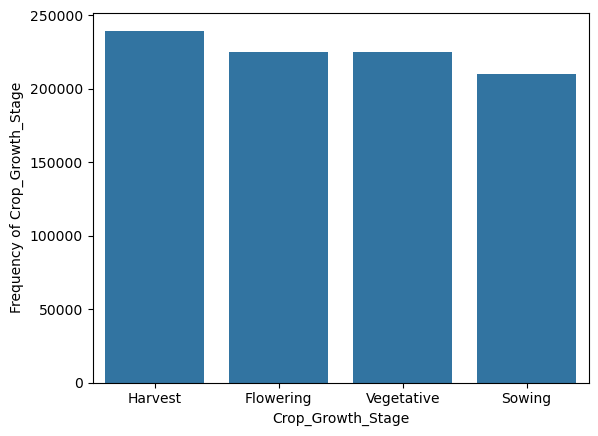

In [17]:
growth_stage_order = df['Crop_Growth_Stage'].value_counts().index
plt.ylabel('Frequency of Crop_Growth_Stage')
sns.countplot(df, x='Crop_Growth_Stage', order=growth_stage_order);

**Facts** :
- Flowering > Vegetative > Sowing > Harvest : order from most water-critical to least water-critical stages

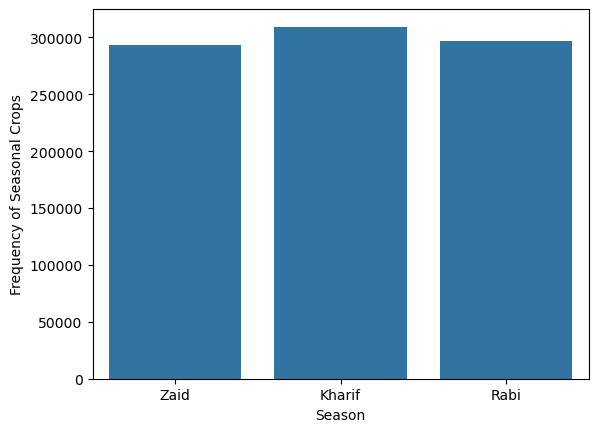

In [18]:
plt.ylabel('Frequency of Seasonal Crops')
sns.countplot(df, x='Season');

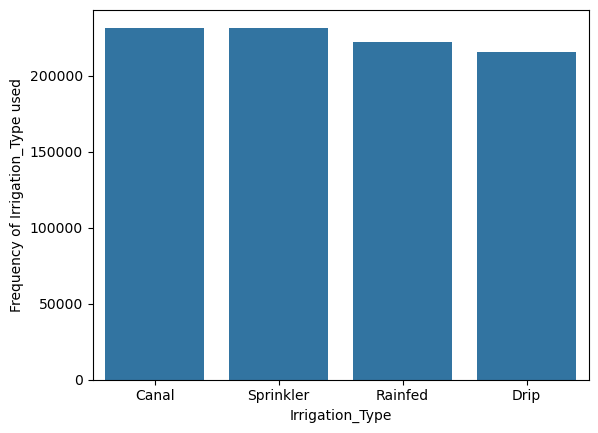

In [19]:
irrigation_type_order = df['Irrigation_Type'].value_counts().index
plt.ylabel('Frequency of Irrigation_Type used')
sns.countplot(df, x='Irrigation_Type', order=irrigation_type_order);

- Traditional method of **Canal Irrigation** is the most adopted irrigation type followed by **Sprinkler** and **Rainfed**

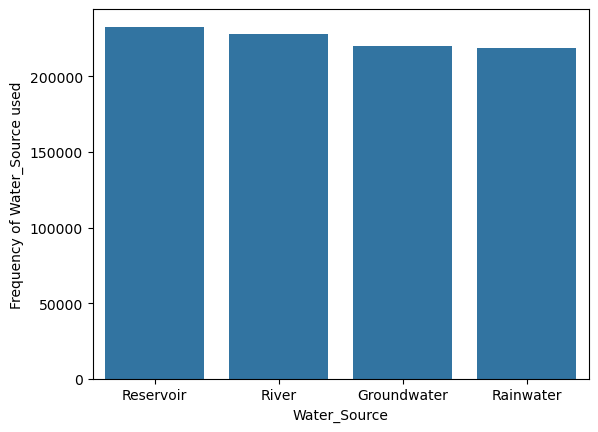

In [20]:
water_source_order = df['Water_Source'].value_counts().index
plt.ylabel('Frequency of Water_Source used')
sns.countplot(df, x='Water_Source', order=water_source_order);

- Reservoirs are the most popular water-sources
- The natural sources from most to least popular : River > Groundwater > Rainwater.

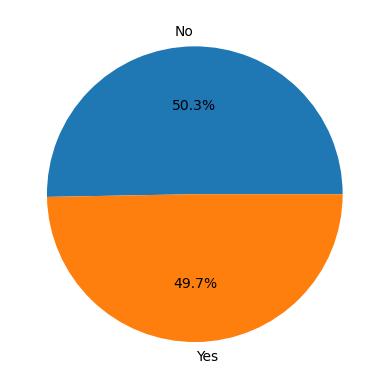

In [21]:
plt.pie(
    x=df['Mulching_Used'].value_counts(),
    labels=df['Mulching_Used'].unique(),
    autopct="%1.1f%%"
);

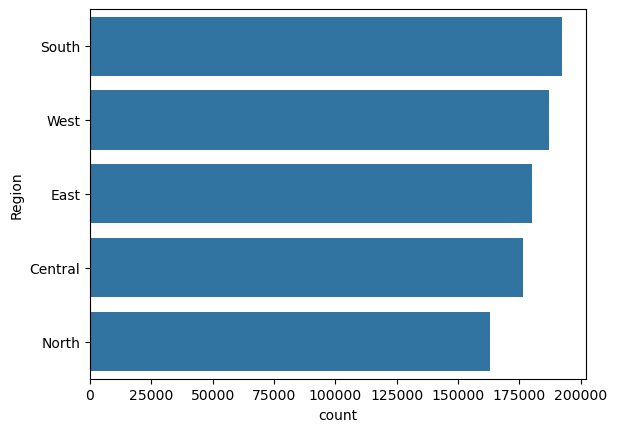

In [22]:
region_order = df['Region'].value_counts().index
sns.countplot(df,y='Region', order=region_order);

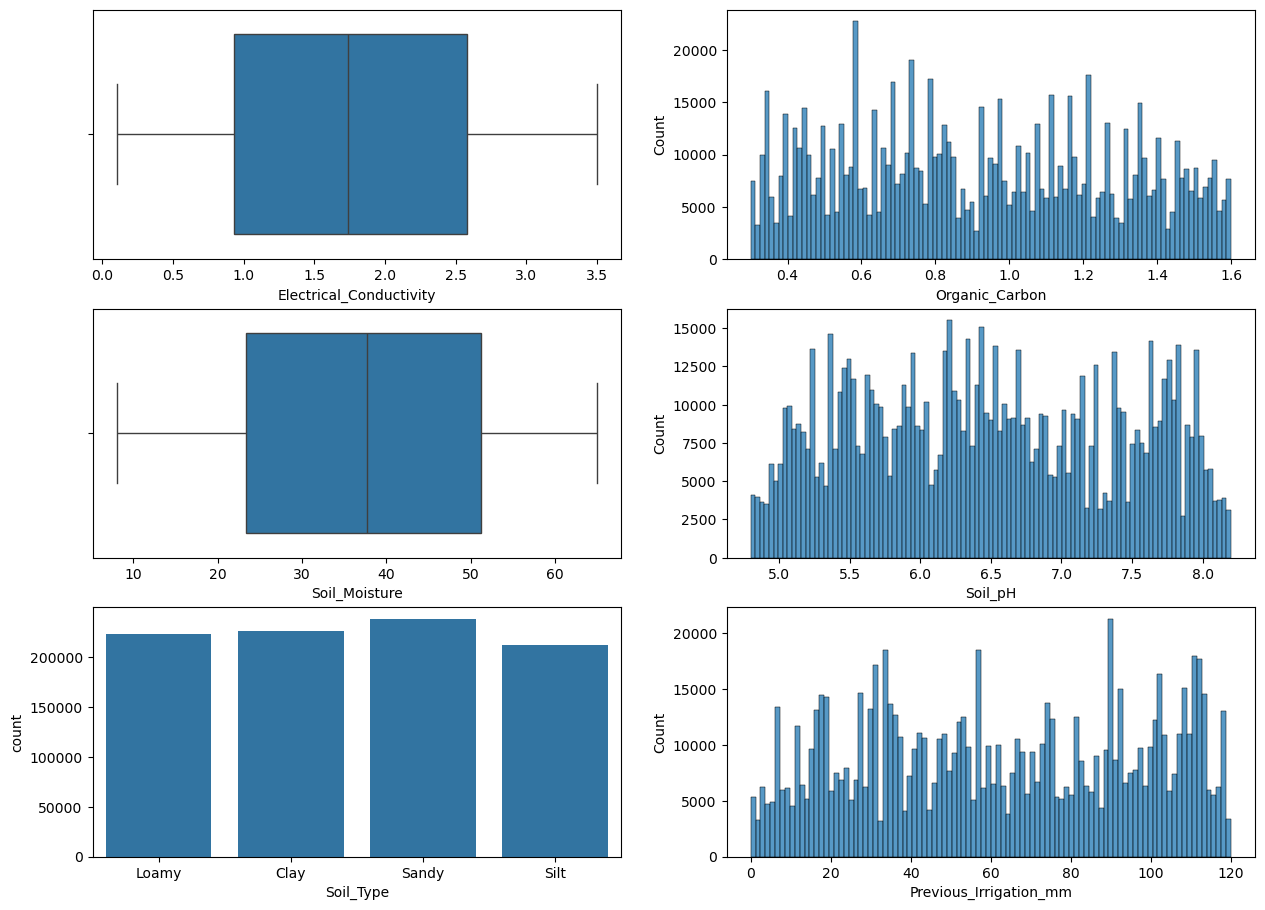

In [31]:
fig, axs = plt.subplots(3,2, figsize=(15, 11))
sns.boxplot(df, x='Electrical_Conductivity', ax=axs[0][0]);
sns.histplot(df, x='Organic_Carbon', ax=axs[0][1]);
sns.boxplot(df, x='Soil_Moisture', ax=axs[1][0]);
sns.histplot(df, x='Soil_pH', ax=axs[1][1]);
sns.countplot(df, x='Soil_Type', ax=axs[2][0]);
sns.histplot(df, x='Previous_Irrigation_mm', ax=axs[2][1]);

**Organic_Carbon**
- Its the carbon amount present in the soil organic matter
- Higher organic carbon amount, better the soil structure as it retains water well
- Soils with higher organic carbon amount have lesser irrigation requirements

**Soil Type**
- Sandy soil - low water retention due to percolation ---> more frequent irrigation need
- Clay soil - high water retention ---> less frequent irrigation needed
- Loamy & Clay soil ----> moderate irrigation needed

**Soil pH**
- Soil_pH is measured in the range from 0 to 14
- When pH < 6.0 ---> Highly acidic soil - Common in wet areas with heavy rainfall → High Irrigation Need
- When pH ranges from 6.0 to 7.5 -  ideal environment for plant growth → Medium (Normal) Irrigation Need
- When pH > 7.5 ---> Highly alkaline soil -  Common in dry, arid regions → High/Complex Irrigation Need

**Soil Moisture**
- Higher the soil moisture, lesser is the demand for frequent/high amount of irrigation

**Electrical Conductivity**
- Its the measure of salt levels in the soil.
- Higher electrical conductivity implies higher levels of salt that prevent the roots from absorbing water.This needs more/extra water to flush the salts deep down past the roots.

**Previous_Irrigation_mm**
- The higher the previous irrigation amount, lesser is the quantity of irrigation need thereafter

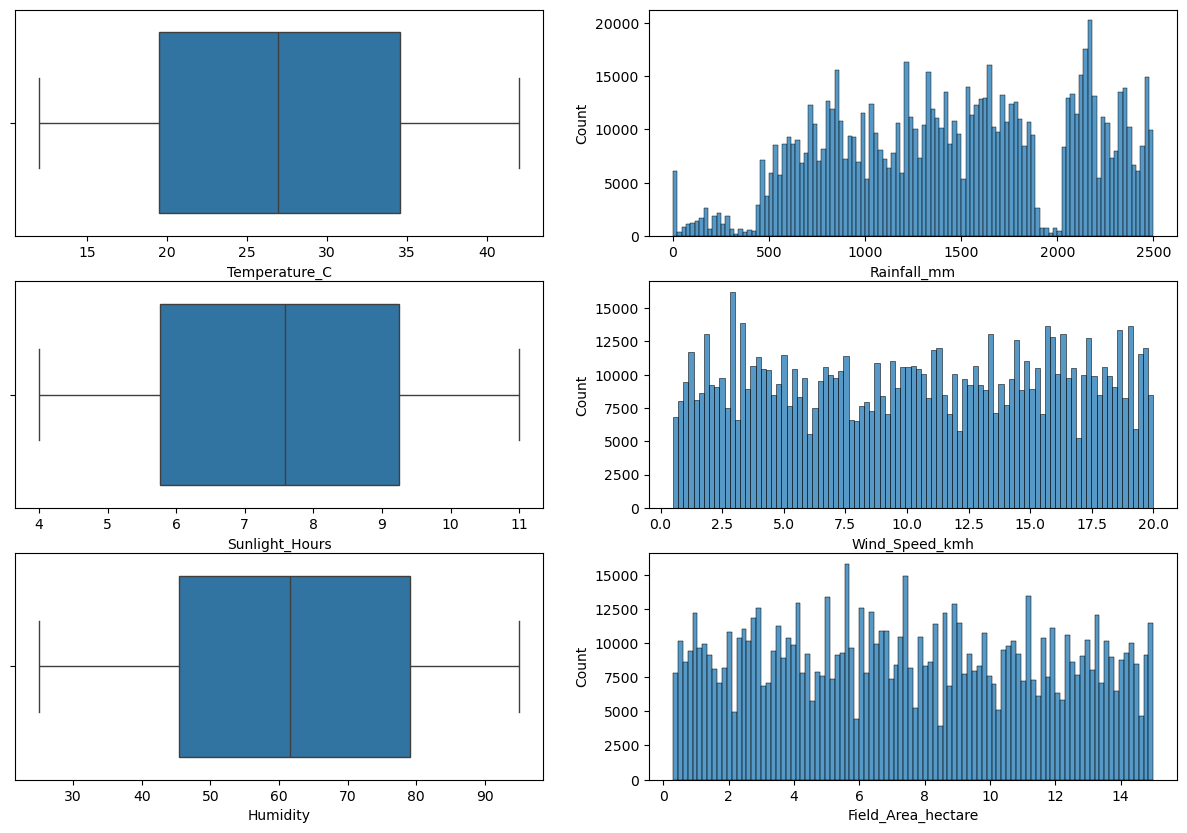

In [28]:
fig, axs = plt.subplots(3,2, figsize=(15, 10))
sns.boxplot(df, x='Temperature_C', ax=axs[0][0]);
sns.histplot(df, x='Rainfall_mm', ax=axs[0][1]);
sns.boxplot(df, x='Sunlight_Hours', ax=axs[1][0]);
sns.histplot(df, x='Wind_Speed_kmh', ax=axs[1][1]);
sns.boxplot(df, x='Humidity', ax=axs[2][0]);
sns.histplot(df, x='Field_Area_hectare', ax=axs[2][1]);            

**Temperature / Sunlight_Hours / Wind_Speed_kmh**

- Higher the temperature or Sunlight_Hours or Wind Speed , higher the amount of irrigation required due to natural process like transpiration, strong winds physically strip moisture away leaving the soil dry, etc

**Humidity / Rainfall**

- The higher amount or humidity or rainfall, higher the moisture content in the environment, lesser is the need of larger irrigation requirements

**Field_Area_hectare**

- Higher the field area, larger volume of irrigation is required

## Bivariate Analysis

In [15]:
numerical_cols

['Soil_pH',
 'Soil_Moisture',
 'Organic_Carbon',
 'Electrical_Conductivity',
 'Temperature_C',
 'Humidity',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Previous_Irrigation_mm']

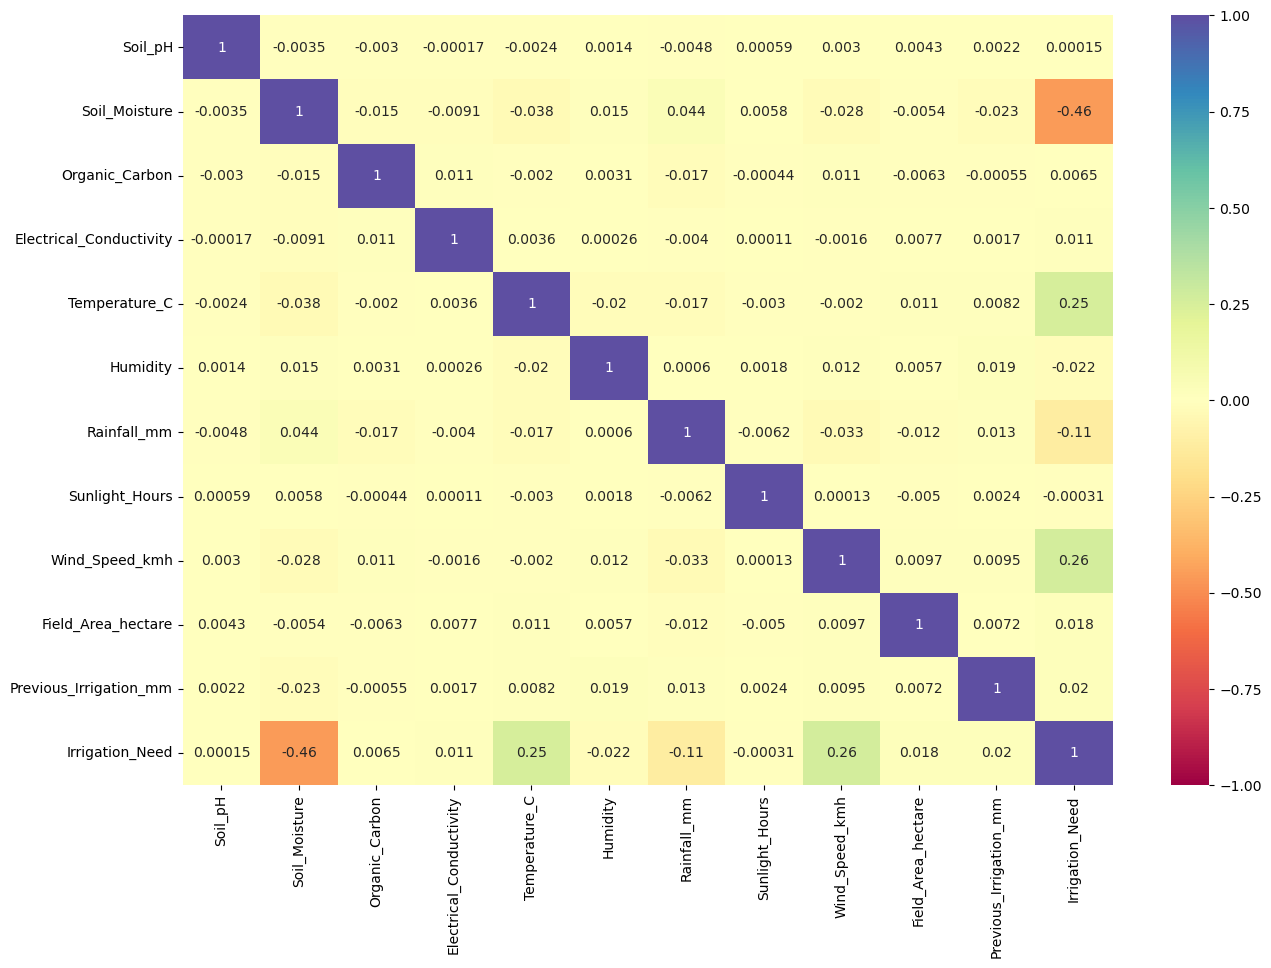

In [16]:
plt.figure(figsize=(15, 10))
sns.heatmap(df_train.corr(numeric_only=True), vmax=1, vmin=-1, cmap='Spectral', annot=True);

- Features `Soil_Mositure` and `Rainfall_mm` have negative correlation with the target feature `Irrigation_Need`.
- Its expected as adequate amount of `Soil_Moisture` and `Rainfall_mm`, can prevent dry spells and reduces the amount of irrigation needed.
- The features `Temperature_C` and `Wind_Speed_kmh` have positive correlation with the target feature `Irrigation_Need`.
- This is because increeasing in temperature or wind speed causes fater rate of moisture soil from the soil surface.So higher amount of irrgation is needed to retain soil moisture.

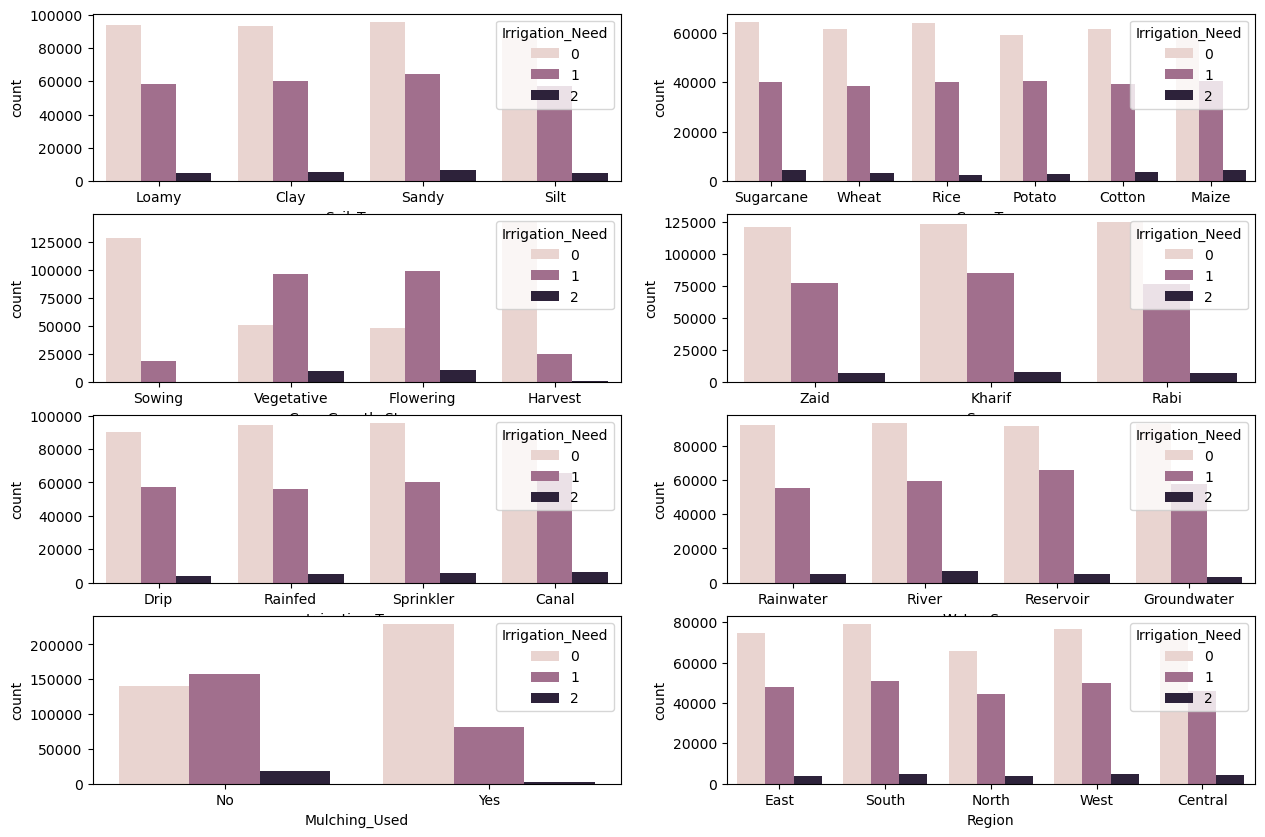

In [17]:
fig, axs = plt.subplots(4, 2, figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    xc, yc = int(i/2), i%2
    sns.countplot(df_train, x=col, hue='Irrigation_Need', ax=axs[xc][yc])

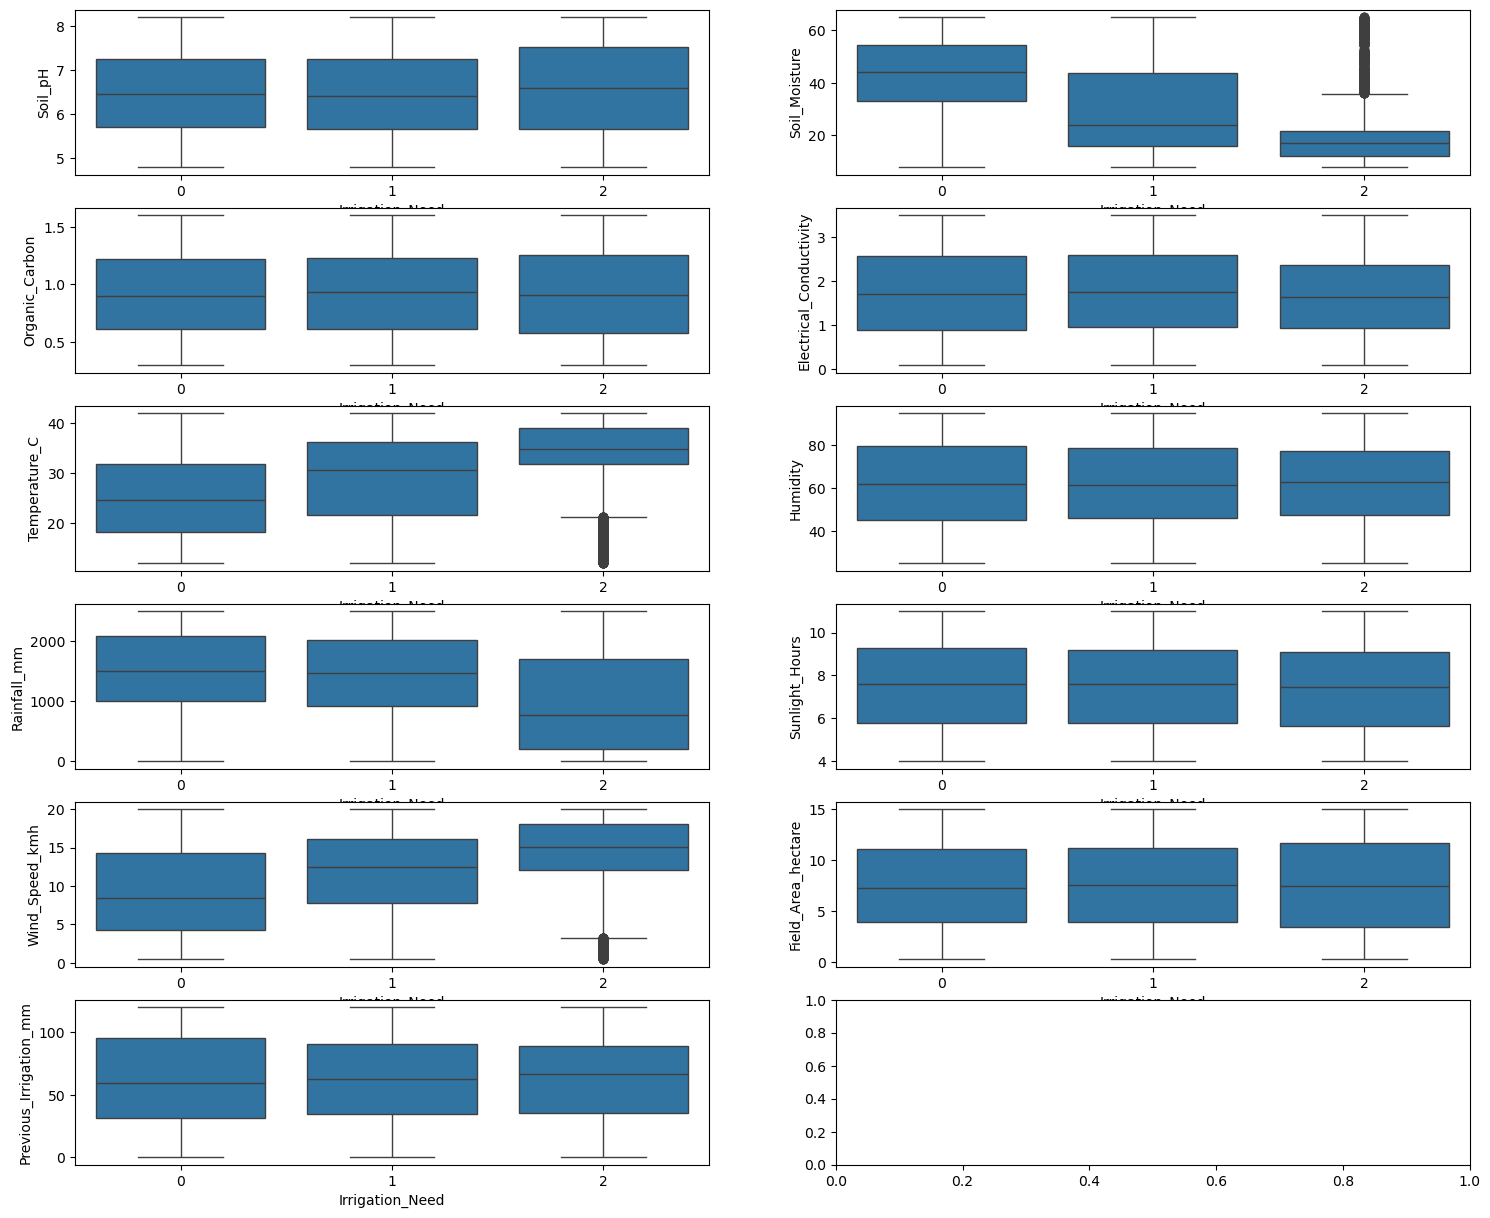

In [18]:
fig, axs = plt.subplots(6, 2, figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    xc, yc = int(i/2), i%2
    sns.boxplot(df_train, y=col, x='Irrigation_Need', ax=axs[xc][yc])

**Soil-pH** :
- Low pH soil stays loose and absorbs water like a sponge, while high pH soil gets hard, blocks water, and forces you to use extra irrigation to wash away harmful salts.

**Soil-Moisture** :
- Soils with moisture level < 20, require high amounts of irrigation.
- Outlier cases like soils with moisture level > 40, also have been shown as consuming higher amount of water by irrigation.

**Organic Carbon & Electrical Conductivity** :
- These features dont seem to have an outrightly strong influence on the target geature `Irrigation_Need` and appears to almost same across all levels.

**Temperature_C & Wind_Speed_kmh** :
- As expected, higher the temperature/wind speed, higher the amount of irrigation needed.Though there exist many outliers where despite low temperature/wind speed, high amount of irrigation is needed.

**Humidity & Rainfall_mm & Electrical_Conductivity & Sunlight_Hours** :

- They dont seem to have much influence on the irrigation amount needed

**Field_Area_hectare & Previous_Irrigation_mm** :

- They dont seem to have much influence on the irrigation amount needed